<a href="https://colab.research.google.com/github/khadijaelewa/bachelorproject/blob/main/enhancements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
import pandas as pd

path = "/content/drive/MyDrive/enhancement/"

df = pd.read_csv(path + "student_performance.csv")

df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [126]:
# Adjust threshold depending on grading scale
df['at_risk'] = df['FinalGrade'].apply(lambda x: 1 if x < 2 else 0)

In [127]:
X = df.drop(columns=[
    'FinalGrade',           # target source
    'ExamScore',            # direct leakage
    'AssignmentCompletion'  # strong proxy (optional but recommended)
])

y = df['at_risk']

In [128]:
X = df[[
    'StudyHours',
    'Discussions',
    'OnlineCourses',
    'Resources',
    'Motivation',
    'StressLevel',
    'Age'
]]

y = df['at_risk']

In [129]:
X = pd.get_dummies(X, drop_first=True)

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='yeo-johnson')

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [132]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced training set:", X_train.shape)

Balanced training set: (11426, 7)


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.5162441985005355
              precision    recall  f1-score   support

           0       0.51      0.52      0.51      1372
           1       0.53      0.52      0.52      1429

    accuracy                           0.52      2801
   macro avg       0.52      0.52      0.52      2801
weighted avg       0.52      0.52      0.52      2801



In [134]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7804355587290254
              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1372
           1       0.78      0.79      0.79      1429

    accuracy                           0.78      2801
   macro avg       0.78      0.78      0.78      2801
weighted avg       0.78      0.78      0.78      2801



In [135]:
from sklearn.svm import SVC

svm = SVC(C=10, kernel='rbf', gamma='scale', probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.5333809353802214
              precision    recall  f1-score   support

           0       0.52      0.54      0.53      1372
           1       0.54      0.53      0.54      1429

    accuracy                           0.53      2801
   macro avg       0.53      0.53      0.53      2801
weighted avg       0.53      0.53      0.53      2801



In [136]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.516244
1,Random Forest,0.780436
2,SVM,0.533381


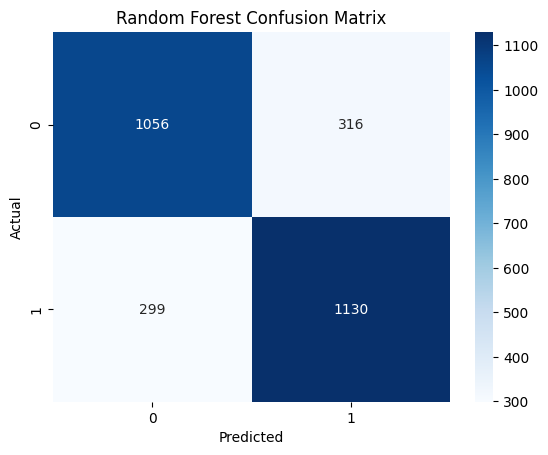

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [138]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_probs = rf.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, rf_probs)

print("AUC Score:", auc_score)

fpr, tpr, _ = roc_curve(y_test, rf_probs)

AUC Score: 0.873349729774945


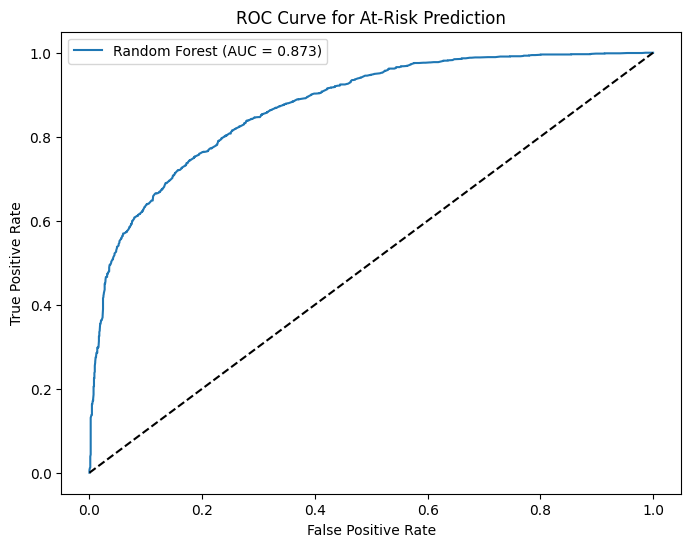

In [139]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for At-Risk Prediction")

plt.legend()
plt.show()